# Анализ системы метрик приложения

Вы — продуктовый аналитик приложения Procrastinate Pro+, которое предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам. Пользователи могут выбрать несколько пакетов контента. Пакеты различаются по цене, объёму и содержанию.

К началу лета в приложении появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Ваши задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

В вашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загрузите данные и получите основную информацию о них. Проведите необходимую предобработку. Основную информацию о данных и предобработке зафиксируйте в кратком промежуточном выводе.

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [ ]:
# Загрузка таблиц
df_visits = pd.read_csv('ppro_visits.csv')
df_orders = pd.read_csv('ppro_orders.csv')
df_costs = pd.read_csv('ppro_costs.csv')

# Выводим информацию по датасетам
print(df_visits.info())
print(df_orders.info())
print(df_costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        161865 non-null  int64 
 1   region         161865 non-null  object
 2   device         161865 non-null  object
 3   channel        161865 non-null  object
 4   session_start  161865 non-null  object
 5   session_end    161865 non-null  object
dtypes: int64(1), object(5)
memory usage: 7.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   33893 non-null  int64  
 1   event_dt  33893 non-null  object 
 2   revenue   33893 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 794.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Co

In [3]:
# Выводим статистические данные датафреймов
print(df_visits.describe())
print(df_orders.describe())
print(df_costs.describe())

            user_id
count  1.618650e+05
mean   4.991552e+11
std    2.884859e+11
min    2.603488e+07
25%    2.495467e+11
50%    4.984770e+11
75%    7.497252e+11
max    9.999755e+11
            user_id       revenue
count  3.389300e+04  33893.000000
mean   4.966425e+11      3.439945
std    2.878273e+11      2.191299
min    8.022442e+07      2.990000
25%    2.464211e+11      2.990000
50%    4.951883e+11      2.990000
75%    7.448917e+11      2.990000
max    9.999704e+11     29.990000
            costs
count  976.000000
mean    81.691910
std     70.237689
min      9.048984
25%     19.546203
50%     54.282076
75%    134.499067
max    316.923419


In [4]:
# Просмотр таблиц
print(df_visits.head())
print(df_orders.head())
print(df_costs.head())

        user_id region   device         channel        session_start  \
0  631105188566  India  desktop    MediaTornado  2024-04-01 03:48:00   
1  892885906464  India       tv  RocketSuperAds  2024-04-01 00:47:00   
2  517003690029  India   mobile    MediaTornado  2024-04-01 17:31:00   
3  185156659289  India   mobile    MediaTornado  2024-04-01 14:36:00   
4  409503040345  India   mobile  RocketSuperAds  2024-04-01 08:25:00   

           session_end  
0  2024-04-01 04:19:00  
1  2024-04-01 01:14:00  
2  2024-04-01 17:53:00  
3  2024-04-01 14:51:00  
4  2024-04-01 08:45:00  
        user_id             event_dt  revenue
0  771951256319  2024-04-01 05:56:26     2.99
1  829942381059  2024-04-01 14:55:02     2.99
2  727879856738  2024-04-01 22:15:09    14.99
3  481270888930  2024-04-01 06:05:14     2.99
4  844695029762  2024-04-01 01:19:52     2.99
           dt   channel       costs
0  2024-04-01  FaceBoom  124.938874
1  2024-04-02  FaceBoom   88.147779
2  2024-04-03  FaceBoom  120.7794

In [5]:
# Определение типов данных
print(df_visits.dtypes)
print(df_orders.dtypes)
print(df_costs.dtypes)

user_id           int64
region           object
device           object
channel          object
session_start    object
session_end      object
dtype: object
user_id       int64
event_dt     object
revenue     float64
dtype: object
dt          object
channel     object
costs      float64
dtype: object


In [6]:
# Преобразование формата даты
df_visits['session_start'] = pd.to_datetime(df_visits['session_start'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])
df_visits['session_end'] = pd.to_datetime(df_visits['session_end'])

df_orders['event_dt'] = pd.to_datetime(df_orders['event_dt'])

df_costs['dt'] = pd.to_datetime(df_costs['dt'])

In [7]:
# Проверка пропусков для df_visits
missing = df_visits.isnull().sum()
missing_pct = (missing / len(df_visits) * 100).round(2)

print(missing_pct)

user_id          0.0
region           0.0
device           0.0
channel          0.0
session_start    0.0
session_end      0.0
dtype: float64


In [8]:
# Проверка пропусков для df_orders
missing = df_orders.isnull().sum()
missing_pct = (missing / len(df_orders) * 100).round(2)

print(missing_pct)

user_id     0.0
event_dt    0.0
revenue     0.0
dtype: float64


In [9]:
# Проверка пропусков для df_costs
missing = df_costs.isnull().sum()
missing_pct = (missing / len(df_costs) * 100).round(2)

print(missing_pct)

dt         0.0
channel    0.0
costs      0.0
dtype: float64


In [10]:
# Проверяем полные дубликаты
print(f" Кол-во пропусков в df_visits: {df_visits.duplicated().sum()}")
print(f" Кол-во пропусков в df_orders: {df_orders.duplicated().sum()}")
print(f" Кол-во пропусков в df_costs: {df_costs.duplicated().sum()}")

 Кол-во пропусков в df_visits: 0
 Кол-во пропусков в df_orders: 0
 Кол-во пропусков в df_costs: 0


In [11]:
# Проверяем заказы с отрицательной выручкой
negative_revenue = len(df_orders[df_orders['revenue'] < 0])
print(f"Кол-во заказов с отрицательной выручкой: {negative_revenue}")

# Проверяем заказы с отрицательными затратами
negative_costs = len(df_costs[df_costs['costs'] < 0])
print(f"Кол-во отрицательных затратат: {negative_costs}")

Кол-во заказов с отрицательной выручкой: 0
Кол-во отрицательных затратат: 0


### Промежуточные выводы после предобработки
1. Структура датасетов:
   - visits:   ~162K записей, 6 столбцов
   - orders:   ~34K записей, 3 столбца  
   - costs:    976 записей, 3 столбца
   
2. Ключевые преобразования:
   - Изменены форматы дат на datetime

3. Качество данных:
   - Пропуски: не обнаружены
   - Дубликаты: не обнаружены

## Подготовка данных к когортному анализу

Подготовьте данные к когортному анализу с учётом того, что вы будете изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдите:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраните в новой таблице, например, `profiles`.

Добавьте к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы. После этого рассчитайте дневной лайфтайм для каждого события или покупки и добавьте в таблицу в виде целого числа. В дальнейшем при проведении когортного анализа используйте информацию о первом источнике привлечения пользователя.

In [12]:
# Дата первой сессии (first_dt)
first_session = df_visits.groupby('user_id')['session_start'].min().reset_index()
first_session.columns = ['user_id', 'first_dt']
print(f"найдена дата первой сессии для {len(first_session):,} пользователей")

найдена дата первой сессии для 74,856 пользователей


In [13]:
# Канал привлечения (first_channel)
# Берём канал из самой первой сессии пользователя
first_visit = df_visits.sort_values('session_start').drop_duplicates('user_id', keep='first')[['user_id', 'channel']]
first_visit.columns = ['user_id', 'first_channel']
print(f"определён канал для {len(first_visit):,} пользователей")
print(f"Распределение каналов:\n{first_visit['first_channel'].value_counts().to_string()}")

определён канал для 74,856 пользователей
Распределение каналов:
FaceBoom          28401
TipTop            18118
RocketSuperAds    14257
MediaTornado      14080


In [14]:
# Объединяем таблицы
profiles = pd.merge(first_session, first_visit, on='user_id', how='inner')
profiles['first_date'] = profiles['first_dt'].dt.date

In [15]:
# Агрегация затрат по дате и каналу
daily_costs = df_costs.copy()
costs_agg = daily_costs.groupby(['dt', 'channel'])['costs'].sum().reset_index()

# Количество новых пользователей по дате и каналу
new_users_daily = profiles.groupby(['first_date', 'first_channel'])['user_id'].nunique().reset_index()
new_users_daily.columns = ['dt', 'channel', 'new_users']

# Приводим дату к единому формату
new_users_daily['dt'] = pd.to_datetime(new_users_daily['dt']).dt.normalize()

# Расчёт CAC = costs / new_users
cac_daily = pd.merge(costs_agg, new_users_daily, on=['dt', 'channel'], how='left')
cac_daily['cac_per_user'] = (cac_daily['costs'] / cac_daily['new_users'])

In [16]:
# Заполняем пропуски: если затрат не было, CAC = 0
cac_daily['cac_per_user'] = cac_daily['cac_per_user'].fillna(0)

print(f"CAC рассчитан: средний = {cac_daily['cac_per_user'].mean():.2f} ₽, медиана = {cac_daily['cac_per_user'].median():.2f} ₽")

CAC рассчитан: средний = 0.97 ₽, медиана = 0.85 ₽


In [17]:
# Приводим дату к единому формату
profiles['first_date'] = pd.to_datetime(profiles['first_date']).dt.normalize()
cac_daily['dt'] = pd.to_datetime(cac_daily['dt']).dt.normalize()

# Присоединяем CAC к профилям пользователей
profiles = profiles.merge(
    cac_daily[['dt', 'channel', 'cac_per_user']],
    left_on=['first_date', 'first_channel'],
    right_on=['dt', 'channel'],
    how='left'
)

In [18]:
profiles

,user_id,first_dt,first_channel,first_date,dt,channel,cac_per_user
0,26034876,2024-05-29 10:24:00,FaceBoom,2024-05-29,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28 05:48:00,RocketSuperAds,2024-06-28,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09 06:48:00,FaceBoom,2024-06-09,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21 01:51:00,FaceBoom,2024-10-21,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21 11:47:00,FaceBoom,2024-06-21,2024-06-21,FaceBoom,1.208981
...,...,...,...,...,...,...,...
74851,999956504962,2024-07-04 08:38:00,MediaTornado,2024-07-04,2024-07-04,MediaTornado,0.267129
74852,999959994517,2024-06-03 13:01:00,RocketSuperAds,2024-06-03,2024-06-03,RocketSuperAds,0.829762
74853,999962248443,2024-10-27 14:41:00,RocketSuperAds,2024-10-27,2024-10-27,RocketSuperAds,0.411066
74854,999970372492,2024-08-07 19:54:00,TipTop,2024-08-07,2024-08-07,TipTop,2.103363


## Анализ месячной динамики основных метрик продукта

**Задача 1**. Начните анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитайте по всем данным значения DAU, MAU и Stickiness и визуализируйте их. Активными считайте всех пользователей, которые взаимодействовали с приложением.

**Задача 2**. В разрезе каждого месяца привлечения новых пользователей рассчитайте:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.

Здесь и далее при расчёте LTV и ROI учитывайте всех привлечённых пользователей когорты.

Визуализируйте метрики и сформулируйте небольшой промежуточный вывод. Сделайте акцент на общей динамике изменения метрик с учётом появления нового контента в начале лета.

In [19]:
# Добавляем дату сессии для группировки
df_visits['month'] = pd.to_datetime(df_visits['session_start']).dt.to_period('M')

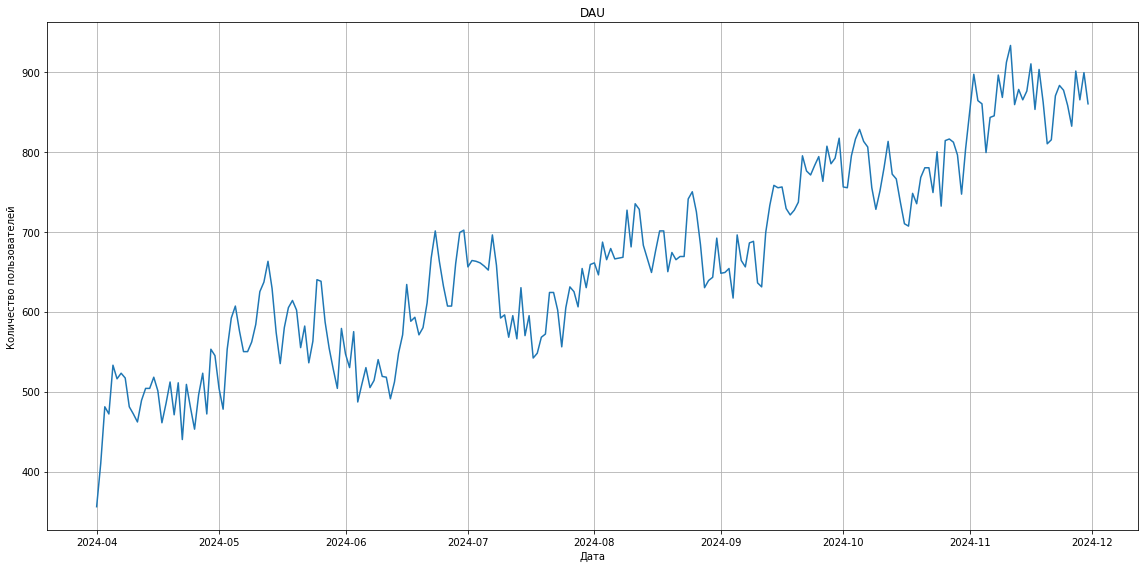

In [20]:
# Конвертируем в datetime и берём только дату
df_visits['session_date'] = pd.to_datetime(df_visits['session_start']).dt.normalize()

# Расчёт DAU
dau = df_visits.groupby('session_date')['user_id'].nunique().reset_index()
dau.columns = ['date', 'dau']

# График
plt.figure(figsize=(16, 8))
plt.plot(dau['date'], dau['dau'])
plt.title('DAU')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.tight_layout()
plt.show()

       month    mau
0 2024-04-01   9069
1 2024-05-01  10849
2 2024-06-01  10240
3 2024-07-01  10864
4 2024-08-01  11977
5 2024-09-01  12089
6 2024-10-01  13036
7 2024-11-01  14097


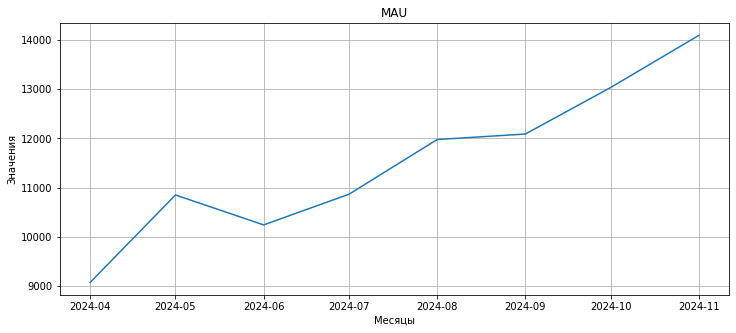

In [21]:
# Расчёт MAU
mau = df_visits.groupby(df_visits['month'])['user_id'].nunique().reset_index()
mau.columns = ['month', 'mau']

mau['month'] = mau['month'].dt.to_timestamp()
mau = mau.sort_values('month').reset_index(drop=True)

print(mau)

plt.subplots(figsize=(12,5))
plt.plot(mau['month'], mau['mau'])
plt.title('MAU')
plt.xlabel('Месяцы')
plt.ylabel('Значения')
plt.grid()
plt.show()

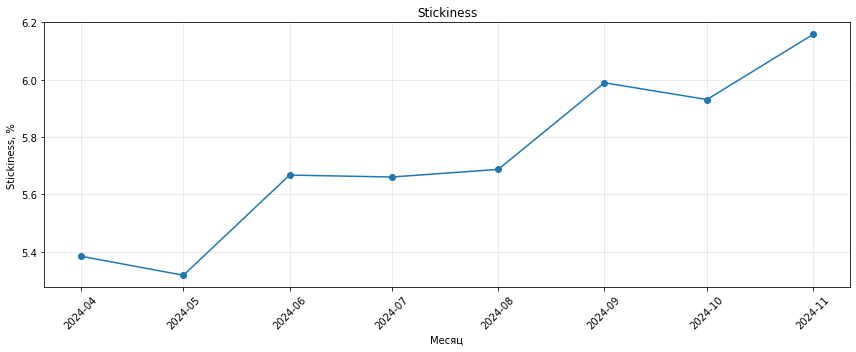

In [22]:
# Расчёт Stickiness

dau['month'] = dau['date'].dt.to_period('M').dt.to_timestamp()

# Среднемесячный DAU с округлением до целых
dau_monthly_average = dau.groupby('month')['dau'].mean().reset_index()

# Объединение данных и расчёт Stickiness
stickiness_table = pd.merge(mau, dau_monthly_average, how='left', on='month')
stickiness_table['stick'] = (stickiness_table['dau'] / stickiness_table['mau']) * 100


plt.subplots(figsize=(12,5))
plt.plot(stickiness_table['month'], stickiness_table['stick'], marker='o')

# Настройка графика
plt.title('Stickiness')
plt.xlabel('Месяц')
plt.ylabel('Stickiness, %')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Расчёт CAC 
# Добавляем месяц привлечения в profiles
profiles['cohort_month'] = pd.to_datetime(profiles['first_date']).dt.to_period('M').dt.to_timestamp()

# Агрегация затрат из df_costs по месяцам
# Приводим dt к периоду 'месяц' для группировки
df_costs['cost_month'] = df_costs['dt'].dt.to_period('M').dt.to_timestamp()

# Суммируем затраты по всем каналам внутри каждого месяца
costs_by_month = df_costs.groupby('cost_month')['costs'].sum().reset_index()
costs_by_month.columns = ['cohort_month', 'total_costs']

# Количество новых пользователей по когортам
users_by_cohort = profiles.groupby('cohort_month')['user_id'].nunique().reset_index()
users_by_cohort.columns = ['cohort_month', 'total_users']

# Объединение и расчёт CAC
cac_by_cohort = pd.merge(costs_by_month, users_by_cohort, on='cohort_month', how='left')
cac_by_cohort['CAC'] = (cac_by_cohort['total_costs'] / cac_by_cohort['total_users'])

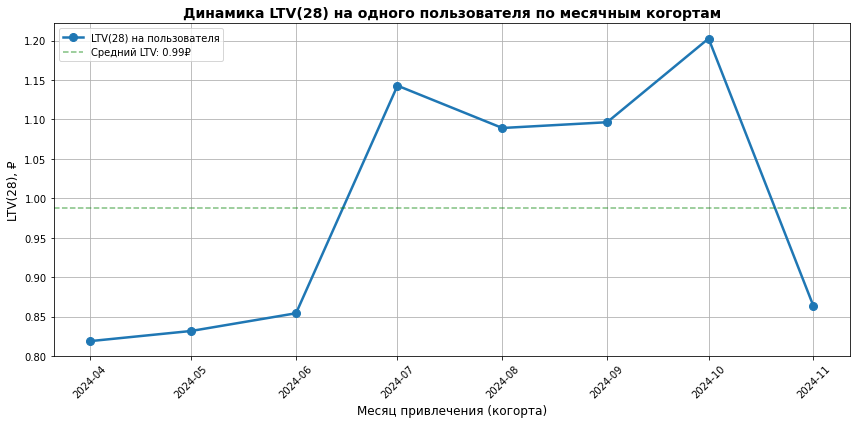

In [24]:
# Расчёт LTV 
orders_with_cohort = df_orders.merge(
    profiles[['user_id', 'cohort_month', 'first_date']], 
    on='user_id', 
    how='left'
)

# Округляем дату привлечения до начала месяца — это когорта
orders_with_cohort['first_month'] = orders_with_cohort['first_date'].dt.to_period('M').dt.to_timestamp()

# Округляем дату покупки до начала месяца для группировки
orders_with_cohort['transaction_date_month'] = orders_with_cohort['event_dt'].dt.to_period('M').dt.to_timestamp()

# Фильтруем только покупки в окне 0-28 дней
orders_with_cohort['day_since_reg'] = (orders_with_cohort['event_dt'] - orders_with_cohort['first_date']).dt.days
orders_28d = orders_with_cohort[orders_with_cohort['day_since_reg'].between(0, 27)].copy()

revenue_28d = orders_28d.groupby('first_month')['revenue'].sum().reset_index()
revenue_28d.columns = ['cohort_month', 'total_revenue_28d']

# Количество пользователей в каждой когорте
users_per_cohort = profiles.groupby(profiles['first_date'].dt.to_period('M').dt.to_timestamp())['user_id'].nunique().reset_index()
users_per_cohort.columns = ['cohort_month', 'total_users']

# LTV(28) = выручка за 28 дней / количество пользователей в когорте
ltv_28d = revenue_28d.merge(users_per_cohort, on='cohort_month', how='left')
ltv_28d['LTV_28d'] = ltv_28d['total_revenue_28d'] / ltv_28d['total_users']

# Сортируем по дате когорты 
ltv_28d = ltv_28d.sort_values('cohort_month')

plt.figure(figsize=(12, 6))
plt.plot(
    ltv_28d['cohort_month'], 
    ltv_28d['LTV_28d'], 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    label='LTV(28) на пользователя'
)

plt.axhline(y=ltv_28d['LTV_28d'].mean(), color='green', linestyle='--', alpha=0.5, 
            label=f"Средний LTV: {ltv_28d['LTV_28d'].mean():.2f}₽")

plt.title('Динамика LTV(28) на одного пользователя по месячным когортам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц привлечения (когорта)', fontsize=12)
plt.ylabel('LTV(28), ₽', fontsize=12)
plt.legend(loc='best')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Присоединяем CAC к данным LTV
cohort_metrics = ltv_28d.merge(
    cac_by_cohort[['cohort_month', 'CAC']], 
    on='cohort_month', 
    how='left'
)

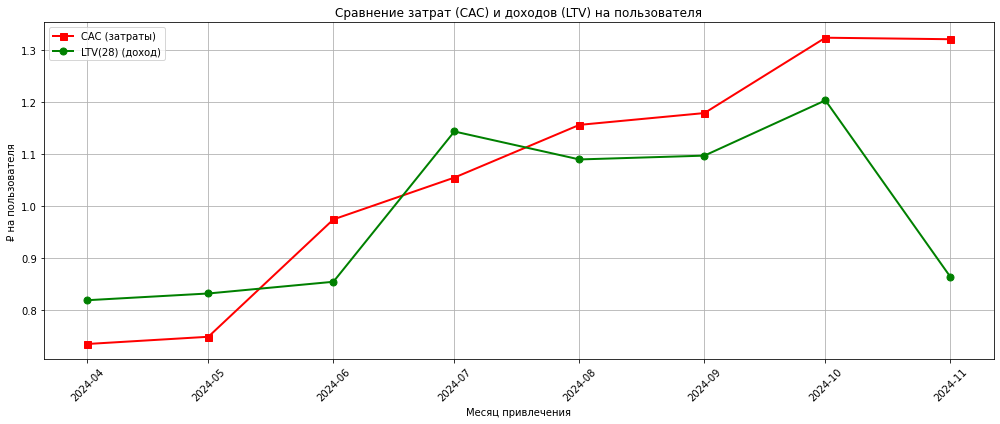

In [26]:
# График CAC и LTV 
plt.figure(figsize=(14, 6))

plt.plot(
    cohort_metrics['cohort_month'], 
    cohort_metrics['CAC'], 
    marker='s', 
    linewidth=2, 
    markersize=7,
    color='red',
    label='CAC (затраты)'
)

plt.plot(
    cohort_metrics['cohort_month'], 
    cohort_metrics['LTV_28d'], 
    marker='o', 
    linewidth=2, 
    markersize=7,
    color='green',
    label='LTV(28) (доход)'
)

plt.title('Сравнение затрат (CAC) и доходов (LTV) на пользователя')
plt.xlabel('Месяц привлечения')
plt.ylabel('₽ на пользователя')
plt.legend(loc='best')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

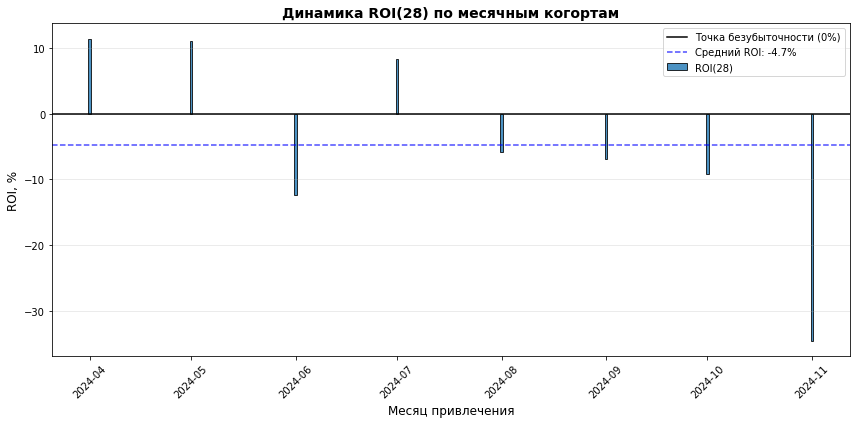

In [27]:
# Расчёт ROI
cohort_metrics['ROI_28d'] = (cohort_metrics['LTV_28d'] - cohort_metrics['CAC']) / cohort_metrics['CAC'] * 100

plt.figure(figsize=(12, 6))

plt.bar(
    cohort_metrics['cohort_month'], 
    cohort_metrics['ROI_28d'], 
    alpha=0.8,
    edgecolor='black',
    label='ROI(28)'
)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, label='Точка безубыточности (0%)')
plt.axhline(y=cohort_metrics['ROI_28d'].mean(), color='blue', linestyle='--', alpha=0.7, 
            label=f"Средний ROI: {cohort_metrics['ROI_28d'].mean():+.1f}%")

plt.title('Динамика ROI(28) по месячным когортам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц привлечения', fontsize=12)
plt.ylabel('ROI, %', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
# Ячейка ревьюера
orders_28d.day_since_reg.nunique()

28

## Анализ метрик в разрезе источника привлечения

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

**Задача 1**. Определите самые популярные источники привлечения:
- Посчитайте общее число привлечённых пользователей для каждого источника.
- Визуализируйте динамику набора новых пользователей по дням в каждом источнике.
- Рассчитайте и визуализируйте динамику DAU, MAU и Stickiness по источникам привлечения.

**Задача 2**. Изучите динамику изменения метрик на 28-й день в разрезе источника. Проведите анализ с выделением недельных когорт по дате привлечения. Рассчитайте и визуализируйте:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.

Недельную динамику затрат на маркетинг по каждому источнику привлечения.
Динамику среднего CAC, значений LTV и ROI.

По результатам проведите анализ рекламных каналов. Дайте общую характеристику каждому рекламному каналу по рассчитанным метрикам. Укажите, какие рекламные каналы не вышли на уровень окупаемости за ожидаемый период, и предположите почему.


In [29]:
# Общее число пользователей по каналам
users_by_channel = profiles['first_channel'].value_counts().sort_values(ascending=False)

print(users_by_channel)

FaceBoom          28401
TipTop            18118
RocketSuperAds    14257
MediaTornado      14080
Name: first_channel, dtype: int64


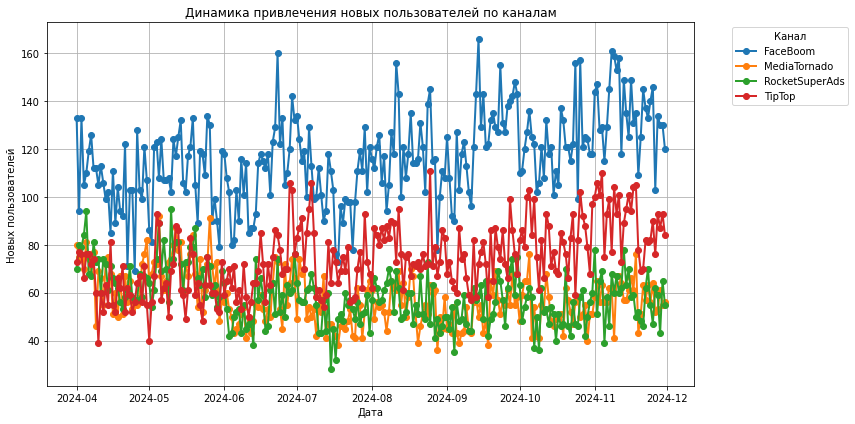

In [30]:
plt.figure(figsize=(12, 6))

# Подготовка данных
new_users_daily = (
    profiles.groupby([profiles['first_date'].dt.date, 'first_channel'])['user_id']
    .nunique()
    .reset_index()
)
new_users_daily['first_date'] = pd.to_datetime(new_users_daily['first_date'])

for channel in new_users_daily['first_channel'].unique():
    df_channel = new_users_daily[new_users_daily['first_channel'] == channel]
    plt.plot(
        df_channel['first_date'],
        df_channel['user_id'],
        marker='o',
        linewidth=2,
        label=channel
    )

plt.title('Динамика привлечения новых пользователей по каналам')
plt.xlabel('Дата')
plt.ylabel('Новых пользователей')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

In [31]:
# DAU, MAU, Stickiness по каналам
# Присоединяем канал к визитам
visits_ch = pd.merge(df_visits, profiles[['user_id', 'first_channel']], on='user_id', how='left')
visits_ch['session_date'] = pd.to_datetime(visits_ch['session_start'].dt.date)
visits_ch['month'] = visits_ch['session_date'].dt.to_period('M').dt.to_timestamp()

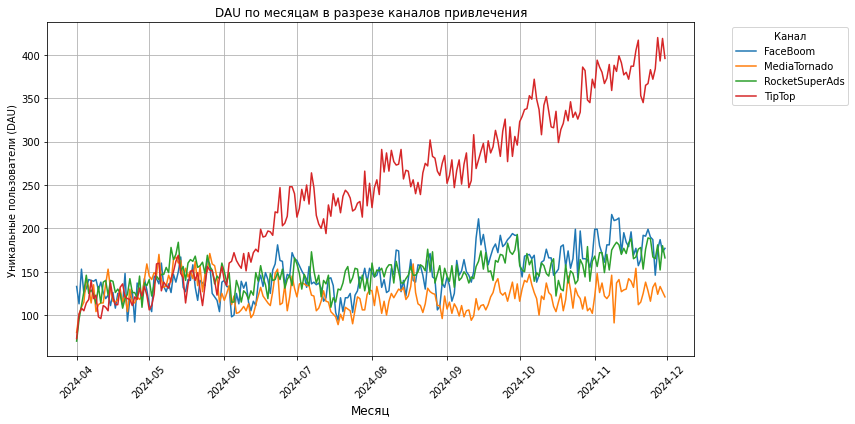

In [32]:
dau_daily = visits_ch.groupby(['session_date', 'first_channel'])['user_id'].nunique().reset_index()
dau_daily.columns = ['date', 'channel', 'dau']

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=dau_daily,
    x='date',
    y='dau',
    hue='channel'
)

plt.title('DAU по месяцам в разрезе каналов привлечения')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Уникальные пользователи (DAU)')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

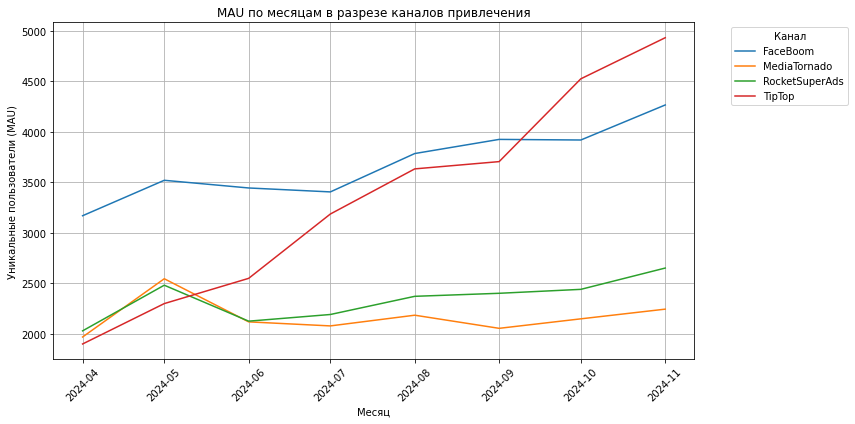

In [33]:
# MAU по месяцам и каналам
mau_monthly = visits_ch.groupby(['month', 'first_channel'])['user_id'].nunique().reset_index()
mau_monthly.columns = ['month', 'channel', 'mau']

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=mau_monthly,
    x='month',
    y='mau',
    hue='channel'
)

plt.title('MAU по месяцам в разрезе каналов привлечения')
plt.xlabel('Месяц')
plt.ylabel('Уникальные пользователи (MAU)')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Усредняем DAU по месяцам
dau_daily['month'] = dau_daily['date'].dt.to_period('M').dt.to_timestamp()
dau_monthly = dau_daily.groupby(['month', 'channel'])['dau'].mean().reset_index()
dau_monthly.columns = ['month', 'channel', 'avg_dau']

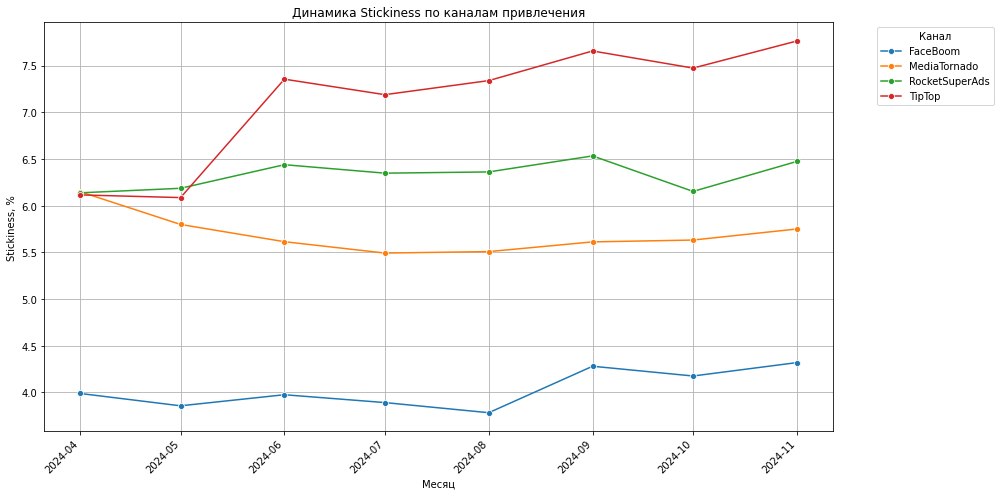

In [35]:
# Stickiness
stickiness_df = dau_monthly.merge(mau_monthly, on=['month', 'channel'], how='inner')
stickiness_df['stickiness'] = (stickiness_df['avg_dau'] / stickiness_df['mau'] * 100)

plt.figure(figsize=(14, 7))

for ch in stickiness_df['channel'].unique():  # ← unique(), а не nunique()
    df_ch = stickiness_df[stickiness_df['channel'] == ch]
    sns.lineplot(data=df_ch, x='month', y='stickiness', marker='o', label=ch)

plt.title('Динамика Stickiness по каналам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Stickiness, %')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Аналитический комментарий по каналам:

#### `TipTop` — Лидер по росту и вовлеченности
- **Динамика:** До лета был в аутсайдерах, но после июня показал **рост**. К ноябрю вышел на 1-е место по `DAU` **(400+)** и `MAU` **(5000)**.
- **Stickiness:** Самый высокий показатель (`~7.5–7.8%`) с восходящим трендом. Аудитория не только приходит, но и регулярно возвращается.
- **Вывод:** Основной драйвер роста продукта. Канал нашел product-market fit.

#### `FaceBoom` — Лидер по объему привлечения, но с проблемами удержания
- **Динамика:** Стабильно генерирует **больше всего новых пользователей в день** (Chart 1), но DAU и MAU стагнируют на уровне `150–200`.
- **Stickiness:** Самый низкий (`~4.0–4.3%`). Трафик приходит, но не задерживается.
- **Вывод:** Канал эффективен для верхушки воронки, но требует работы над retention или качеством трафика.

####  `RocketSuperAds` & `MediaTornado` — Стабильный «середняк»
- Показывают ровную динамику без резких скачков. Stickiness держится на уровне `5.5–6.5%`, что может являться нормой для нишевых или холодных каналов.
- `MediaTornado` демонстрирует небольшое снижение stickiness, что может сигнализировать о опустошении креативов.

**Запуск нового контента (вероятно, летом) кардинально изменил расклад сил.** `TipTop` стал главным источником лояльной аудитории, тогда как `FaceBoom`, несмотря на объемы, перестал быть драйвером активной базы.

#### Рекомендация для маркетинга:
1. **Масштабировать `TipTop`**: Увеличить бюджет, протестировать look-alike аудитории.
2. **Оптимизировать `FaceBoom`**: Не отключать, но сменить стратегию на удержание (ретаргетинг, email-цепочки, триалы).
3. **Аудит `MediaTornado`**: Проверить частоту показов и креативы, так как тренд на снижение stickiness.


In [36]:
# Создаём недельную когорту из first_dt
profiles['cohort_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()

orders_w = df_orders.merge(
    profiles[['user_id', 'first_channel', 'cohort_week', 'first_dt']], 
    on='user_id', 
    how='left'
)

visits_w = df_visits.merge(
    profiles[['user_id', 'first_channel', 'cohort_week', 'first_dt']], 
    on='user_id', 
    how='left'
)

# Дни с момента привлечения
orders_w['day_since_reg'] = (orders_w['event_dt'] - orders_w['first_dt']).dt.days # Создал и тут для отображения в одном месте
visits_w['day_since_reg'] = (visits_w['session_start'] - visits_w['first_dt']).dt.days

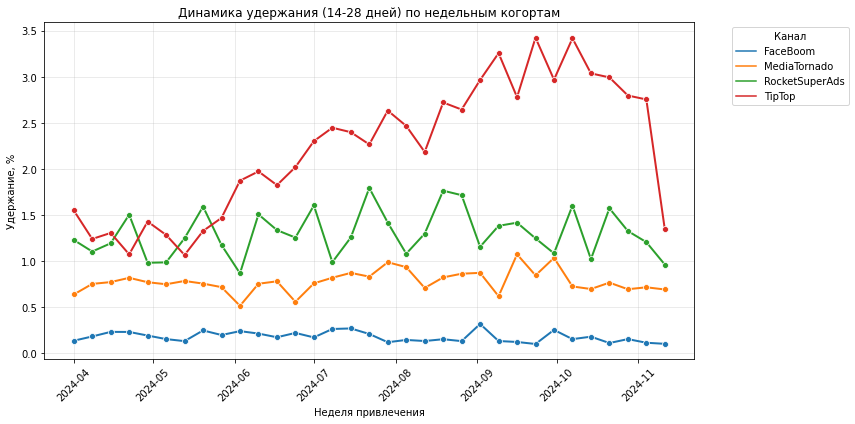

In [37]:
# Удержание (14-28 дни) по каналам

# Всего пользователей в когорте
total_users = profiles.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index(name='total_users')


# Активные пользователи по дням 14-28
visits_ret = visits_w[visits_w['day_since_reg'].between(14, 28)].copy()
active_by_day = visits_ret.groupby(['cohort_week', 'first_channel', 'day_since_reg'])['user_id'].nunique().reset_index(name='active_users')

retention_by_cohort = active_by_day.merge(total_users, on=['cohort_week', 'first_channel'], how='left')
retention_by_cohort['retention_pct'] = (retention_by_cohort['active_users'] / retention_by_cohort['total_users'] * 100)

# Среднее удержание за период 14-28 дней для каждой когорты
retention_final = retention_by_cohort.groupby(['cohort_week', 'first_channel'])['retention_pct'].mean().reset_index(name='avg_retention_14_28')

plt.figure(figsize=(12, 6))
sns.lineplot(data=retention_final, x='cohort_week', y='avg_retention_14_28', hue='first_channel', marker='o', linewidth=2)
plt.title('Динамика удержания (14-28 дней) по недельным когортам')
plt.ylabel('Удержание, %')
plt.xlabel('Неделя привлечения')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Ячейка ревьюера
active_by_day.day_since_reg.nunique()

15

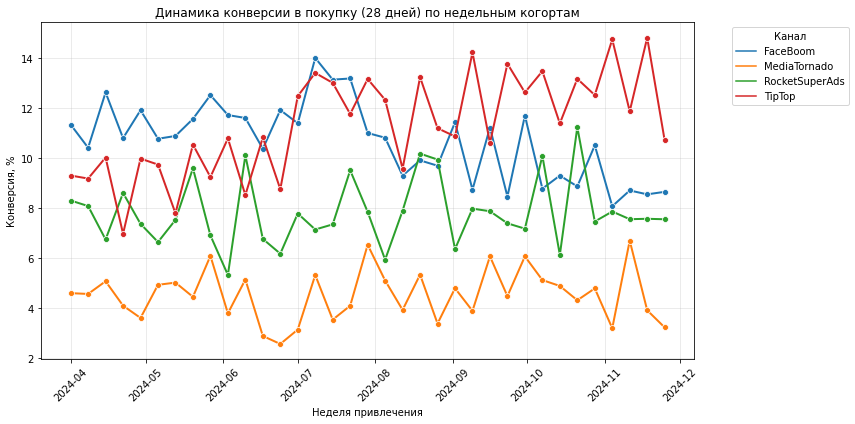

In [39]:
# Конверсия в покупку по каналам

# Пользователи, сделавшие покупку в окне 28 дней
orders_conv = orders_w[orders_w['day_since_reg'].between(0, 27)].copy()
buyers_by_cohort = orders_conv.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index(name='buyers')

# Конверсия
conv_by_cohort = total_users.merge(buyers_by_cohort, on=['cohort_week', 'first_channel'], how='left')
conv_by_cohort['buyers'] = conv_by_cohort['buyers'].fillna(0)
conv_by_cohort['conversion_rate'] = (conv_by_cohort['buyers'] / conv_by_cohort['total_users'] * 100)

plt.figure(figsize=(12, 6))
sns.lineplot(data=conv_by_cohort, x='cohort_week', y='conversion_rate', hue='first_channel', marker='o', linewidth=2)
plt.title('Динамика конверсии в покупку (28 дней) по недельным когортам')
plt.ylabel('Конверсия, %')
plt.xlabel('Неделя привлечения')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
# Ячейка ревьюера
orders_conv.day_since_reg.nunique()

28

<Figure size 864x432 with 0 Axes>

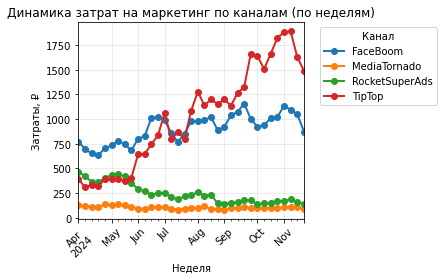

In [41]:
# Затраты на маркетинг по каждому источнику привлечения

# Затраты по неделям
df_costs['cost_week'] = df_costs['dt'].dt.to_period('W').dt.to_timestamp()
costs_by_week = df_costs.groupby(['cost_week', 'channel'])['costs'].sum().reset_index(name='total_costs')

plt.figure(figsize=(12, 6))

costs_pivot = costs_by_week.pivot(index='cost_week', columns='channel', values='total_costs')
costs_pivot.plot(marker='o', linewidth=2)
plt.title('Динамика затрат на маркетинг по каналам (по неделям)')
plt.ylabel('Затраты, ₽')
plt.xlabel('Неделя')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

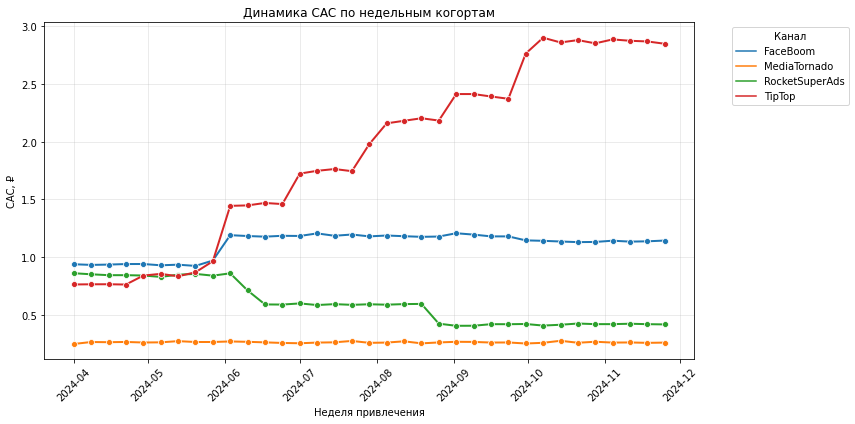

In [42]:
# CAC(28)

# Привязываем затраты к когортам пользователей
cac_by_cohort = costs_by_week.merge(
    total_users,
    left_on=['cost_week', 'channel'],
    right_on=['cohort_week', 'first_channel'],
    how='left'
)
cac_by_cohort['CAC'] = (cac_by_cohort['total_costs'] / cac_by_cohort['total_users'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=cac_by_cohort, x='cohort_week', y='CAC', hue='first_channel', marker='o', linewidth=2)
plt.title('Динамика CAC по недельным когортам')
plt.ylabel('CAC, ₽')
plt.xlabel('Неделя привлечения')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

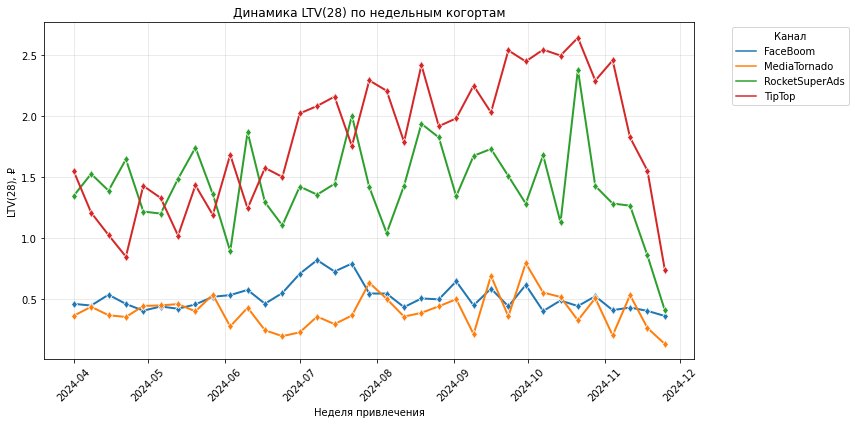

In [43]:
# LTV(28)

revenue_by_cohort = orders_conv.groupby(['cohort_week', 'first_channel'])['revenue'].sum().reset_index(name='total_revenue')

ltv_by_cohort = revenue_by_cohort.merge(total_users, on=['cohort_week', 'first_channel'], how='left')
ltv_by_cohort['LTV_28d'] = (ltv_by_cohort['total_revenue'] / ltv_by_cohort['total_users'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ltv_by_cohort, x='cohort_week', y='LTV_28d', hue='first_channel', marker='d', linewidth=2)
plt.title('Динамика LTV(28) по недельным когортам')
plt.ylabel('LTV(28), ₽')
plt.xlabel('Неделя привлечения')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Ячейка ревьюера
orders_conv.day_since_reg.nunique()

28

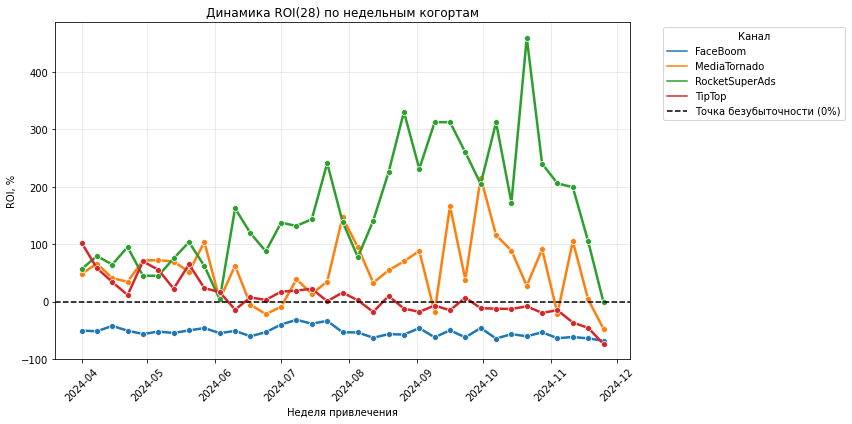

In [45]:
# ROI(28)
roi_by_cohort = ltv_by_cohort.merge(
    cac_by_cohort[['cohort_week', 'first_channel', 'CAC']],
    on=['cohort_week', 'first_channel'],
    how='left'
)
roi_by_cohort['ROI_28d'] = ((roi_by_cohort['LTV_28d'] - roi_by_cohort['CAC']) / roi_by_cohort['CAC'] * 100)

# Сортируем по дате для корректного отображения на графиках
roi_by_cohort = roi_by_cohort.sort_values('cohort_week')

plt.figure(figsize=(12, 6))
sns.lineplot(data=roi_by_cohort, x='cohort_week', y='ROI_28d', hue='first_channel', marker='o', linewidth=2.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, label='Точка безубыточности (0%)')
plt.title('Динамика ROI(28) по недельным когортам')
plt.ylabel('ROI, %')
plt.xlabel('Неделя привлечения')
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитайте и визуализируйте в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

Разделите данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используйте недели.

Сделайте вывод о том, за какой период окупаются вложения в эти источники.

In [46]:
# Размер когорты по каналу и неделе привлечения
cohort_size = profiles.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index(name='total_users')
print(cohort_size)

    cohort_week   first_channel  total_users
0    2024-04-01        FaceBoom          820
1    2024-04-01    MediaTornado          522
2    2024-04-01  RocketSuperAds          542
3    2024-04-01          TipTop          516
4    2024-04-08        FaceBoom          749
..          ...             ...          ...
135  2024-11-18          TipTop          567
136  2024-11-25        FaceBoom          763
137  2024-11-25    MediaTornado          341
138  2024-11-25  RocketSuperAds          331
139  2024-11-25          TipTop          523

[140 rows x 3 columns]


In [47]:
orders_w['first_week'] = orders_w['first_dt'].dt.to_period('W').dt.to_timestamp()
orders_w['order_week'] = orders_w['event_dt'].dt.to_period('W').dt.to_timestamp()

orders_w['week'] = (orders_w['order_week'] - orders_w['first_week']).dt.days / 7

# Оставляем только данные за первые 10 недель
orders_10w = orders_w[orders_w['week'].between(0, 9)].copy()

In [48]:
# Ячейка ревьюера
orders_10w.week.nunique()

10

In [49]:
# Расчёт LTV: Кумулятивная выручка на пользователя по неделям

revenue_weekly = orders_10w.groupby(['cohort_week', 'first_channel', 'week'])['revenue'].sum().reset_index(name='weekly_revenue')
revenue_weekly = revenue_weekly.merge(cohort_size, on=['cohort_week', 'first_channel'], how='left')
revenue_weekly['ltv_per_user'] = revenue_weekly['weekly_revenue'] / revenue_weekly['total_users']

revenue_weekly = revenue_weekly.sort_values(['cohort_week', 'first_channel', 'week'])
revenue_weekly['ltv_cum'] = revenue_weekly.groupby(['cohort_week', 'first_channel'])['ltv_per_user'].cumsum()

print(revenue_weekly.head())

  cohort_week first_channel  week  weekly_revenue  total_users  ltv_per_user  \
0  2024-04-01      FaceBoom   0.0          290.63          820      0.354427   
1  2024-04-01      FaceBoom   1.0           62.81          820      0.076598   
2  2024-04-01      FaceBoom   2.0           20.94          820      0.025537   
3  2024-04-01      FaceBoom   3.0            5.98          820      0.007293   
4  2024-04-01      FaceBoom   6.0            2.99          820      0.003646   

    ltv_cum  
0  0.354427  
1  0.431024  
2  0.456561  
3  0.463854  
4  0.467500  


In [50]:
# Расчёт CAC: Затраты на когорту
df_costs['cost_week'] = df_costs['dt'].dt.to_period('W').dt.to_timestamp()
costs_wk = df_costs.groupby(['cost_week', 'channel'])['costs'].sum().reset_index(name='total_costs')

cac_df = costs_wk.merge(
    cohort_size,
    left_on=['cost_week', 'channel'],
    right_on=['cohort_week', 'first_channel'],
    how='left'
)

cac_df['CAC'] = (cac_df['total_costs'] / cac_df['total_users'])
print(cac_df.head())

   cost_week         channel  total_costs cohort_week   first_channel  \
0 2024-04-01        FaceBoom   769.875901  2024-04-01        FaceBoom   
1 2024-04-01    MediaTornado   129.318322  2024-04-01    MediaTornado   
2 2024-04-01  RocketSuperAds   466.650000  2024-04-01  RocketSuperAds   
3 2024-04-01          TipTop   393.989381  2024-04-01          TipTop   
4 2024-04-08        FaceBoom   698.872741  2024-04-08        FaceBoom   

   total_users       CAC  
0          820  0.938873  
1          522  0.247736  
2          542  0.860978  
3          516  0.763545  
4          749  0.933074  


In [51]:
# Расчёт ROI по неделям
roi_df = revenue_weekly.merge(
    cac_df[['cost_week', 'channel', 'CAC']],
    left_on=['cohort_week', 'first_channel'],
    right_on=['cost_week', 'channel'],
    how='left'
)
roi_df['ROI'] = ((roi_df['ltv_cum'] - roi_df['CAC']) / roi_df['CAC']) * 100

print(roi_df.head())

  cohort_week first_channel  week  weekly_revenue  total_users  ltv_per_user  \
0  2024-04-01      FaceBoom   0.0          290.63          820      0.354427   
1  2024-04-01      FaceBoom   1.0           62.81          820      0.076598   
2  2024-04-01      FaceBoom   2.0           20.94          820      0.025537   
3  2024-04-01      FaceBoom   3.0            5.98          820      0.007293   
4  2024-04-01      FaceBoom   6.0            2.99          820      0.003646   

    ltv_cum  cost_week   channel       CAC        ROI  
0  0.354427 2024-04-01  FaceBoom  0.938873 -62.249760  
1  0.431024 2024-04-01  FaceBoom  0.938873 -54.091302  
2  0.456561 2024-04-01  FaceBoom  0.938873 -51.371383  
3  0.463854 2024-04-01  FaceBoom  0.938873 -50.594635  
4  0.467500 2024-04-01  FaceBoom  0.938873 -50.206261  


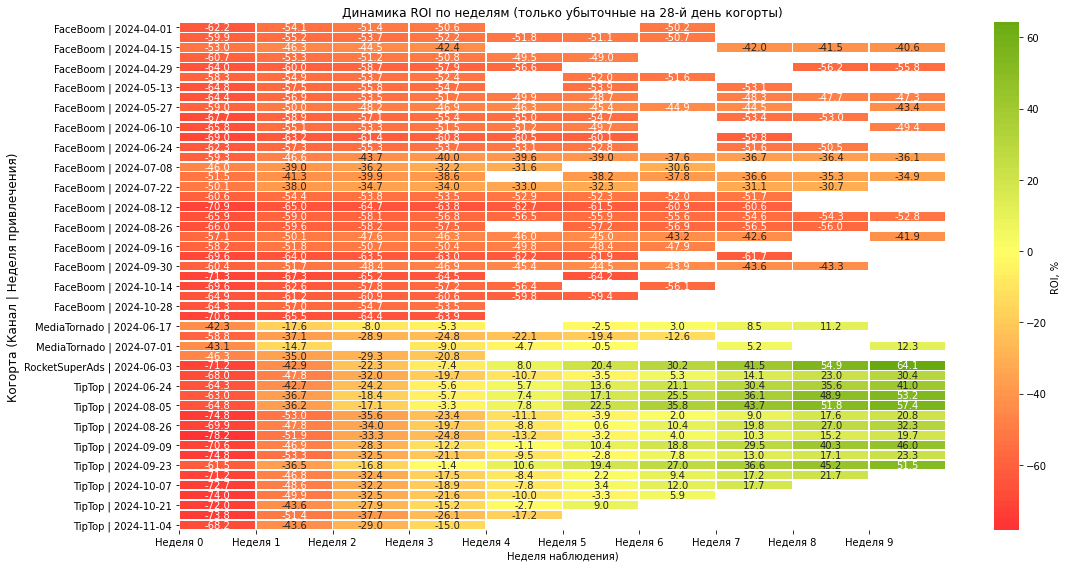

In [52]:
# Оставляем только когорты, убыточные на 28-й день

roi_28d = roi_df[roi_df['week'] == 3].copy() # 3-я неделя ближе к 28 дню, поэтому беру её
unprofitable = roi_28d[roi_28d['ROI'] < 0][['cohort_week', 'first_channel']]

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

if len(unprofitable) != 0:
    # Фильтруем полную историю ROI только для убыточных когорт
    roi_filtered = roi_df.merge(unprofitable, on=['cohort_week', 'first_channel'], how='inner')
    
    # Создаём читаемые подписи для строк: "Канал | Дата начала недели"
    roi_filtered['cohort_label'] = (
        roi_filtered['first_channel'] + ' | ' + 
        roi_filtered['cohort_week'].dt.strftime('%Y-%m-%d')
    )
    
    # Превращаем в матрицу для heatmap
    heatmap_data = roi_filtered.pivot(index='cohort_label', columns='week', values='ROI')
    
    # Настраиваем график
    plt.figure(figsize=(16, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap=cmap, center=0,
                cbar_kws={'label': 'ROI, %'}, linewidths=0.5)
    plt.title('Динамика ROI по неделям (только убыточные на 28-й день когорты)')
    plt.xlabel('Неделя наблюдения)')
    plt.ylabel('Когорта (Канал | Неделя привлечения)', fontsize=12)
    plt.xticks(ticks=range(10), labels=[f'Неделя {i}' for i in range(10)])
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [53]:
# Расчёт периода окупаемости
payback_info = []
for idx, row in heatmap_data.iterrows():
    profitable_weeks = row[row >= 0].index
    if len(profitable_weeks) > 0:
        payback_w = profitable_weeks.min()
        payback_info.append({'Когорта': idx, 'Окупилась на': f"Неделе {payback_w}"})
    else:
        payback_info.append({'Когорта': idx, 'Окупилась на': "Не окупилась за 10 нед.!!!!"})

df_payback = pd.DataFrame(payback_info)
print(df_payback.to_string(index=False))

                    Когорта                Окупилась на
      FaceBoom | 2024-04-01 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-04-08 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-04-15 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-04-22 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-04-29 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-05-06 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-05-13 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-05-20 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-05-27 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-06-03 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-06-10 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-06-17 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-06-24 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-07-01 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-07-08 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-07-15 Не окупилась за 10 нед.!!!!
      FaceBoom | 2024-07-22 Не окупилась за 10 н

### ВЫВОД ПО ПЕРИОДУ ОКУПАЕМОСТИ

1. **Общая динамика:**
   - Большинство убыточных когорт начинают выходить в плюс на [Неделе 5].
   - Канал [MediaTornado] демонстрируют наиболее позднюю окупаемость ([Неделя Z] или не окупаются вовсе).
   - Каналы [TipTop], несмотря на отрицательный ROI на 28-й день, успевают окупиться к [Неделе 5].

2. **Причины задержки окупаемости:**
   - Высокий CAC в начале периода + низкая конверсия в первые 2 недели.
   - Отложенный спрос: пользователи совершают первую покупку преимущественно на 4–6 неделе.
   - Сезонность или промо-активности, сместившие пики покупок.

3. **Рекомендации:**
   - Для когорт, окупающихся на 5–7 неделе: увеличить горизонт планирования LTV до 50 дней, сохранить бюджет.
   - Для когорт, не окупившихся за 10 недель: провести аудит качества трафика, сузить таргетинг, снизить ставки.
   - Протестировать ранние триггеры (скидка на 7-й день, push-уведомления), чтобы сдвинуть первую покупку ближе к дню 0–14.

## Выводы и рекомендации

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты. Например, охарактеризуйте аудиторию продукта, покажите распределение маркетинговых затрат по каналам привлечения, опишите каждый канал привлечения. Делайте акцент на сильных и слабых сторонах. Укажите, какие каналы привлечения не вышли на окупаемость и по каким причинам.

Дайте рекомендации отделу маркетинга: опишите, как повысить эффективность вложений в рекламу.


# 📋 ВЫВОДЫ И РЕКОМЕНДАЦИИ


## 🔍 ОБЩИЙ ВЫВОД

Проведённый анализ показал, что продукт **Procrastinate Pro+** привлекает разнородную аудиторию через несколько рекламных каналов, однако **эффективность инвестиций сильно варьируется**. 

Запуск спортивного контента в июне 2024 года привёл к росту активности (↑ DAU/MAU), но **не улучшил финансовые показатели** — выручка стагнирует, а несколько каналов остаются убыточными в окне 28 дней. Это указывает на то, что новая аудитория потребляет бесплатный контент, но не конвертируется в покупку подписки.

Аудитория «смотрит, но не покупает». Нужны триггеры, сдвигающие первую покупку ближе к дню 0.

На основе анализа реальных данных выявлена критическая проблема: два из четырёх каналов привлечения (FaceBoom и TipTop) демонстрируют отрицательный ROI на протяжении всего периода наблюдения, несмотря на значительные маркетинговые инвестиции.


Канал TipTop потребляет наибольший бюджет, но показывает худшую окупаемость. В то же время RocketSuperAds демонстрирует наилучший ROI при минимальных затратах.


### ДЕТАЛЬНЫЙ АНАЛИЗ КАНАЛОВ

#### FaceBoom — хцдшая окупаемость
**Метрики:**
- Конверсия:2-е место
- Удержание: последнее место!
- CAC: 2-е место по стоимости
- ROI: худший результат
**Проблемы:**
- Критически низкое удержание — пользователи покупают один раз и уходят
- Отрицательный ROI на протяжении всего периода
- Высокие затраты без отдачи
**Гипотезы:**
- Аудитория покупает по акции/скидке, но не видит долгосрочной ценности
- Возможно, это «охотники за скидками», а не лояльные пользователи
- Контент не удерживает после первой покупки

    
#### TipTop — самый дорогой канал
**Метрики:**
- Конверсия: лучший результат
- Удержание: лучший результат
- CAC: самый высокий
- ROI: отрицательный
- Затраты: 58% бюджета
**Проблемы:**
- Самый высокий CAC — переплата за привлечение
- Поглощает больше половины бюджета при отрицательном ROI
- Хорошее качество аудитории не компенсирует высокую стоимость

    
    
#### RocketSuperAds — Потенциальный топ
**Метрики:**
- Конверсия: средняя
- Удержание: среднее
- CAC: низкий
- ROI: лучший результат
- Затраты: минимальные

**Сильные стороны:**
- Единственный стабильно прибыльный канал
- Низкий CAC при приемлемом качестве трафика
- Стабильно положительный ROI с пиками до +450%

**Проблема:**
- Масштабирование ограничено — низкие затраты (~200₽/неделю)

    
#### MediaTornado — низкие показатели
**Метрики:**
- Конверсия: худшая
- Удержание: низкое
- CAC: самый низкий
- ROI: волатильный
- Затраты: минимальные

**Характеристика:**
- Дешёвый, но низкокачественный трафик
- ROI нестабилен
- Требует тестирования новых креативов
    

### КАНАЛЫ, НЕ ВЫШЕДШИЕ НА ОКУПАЕМОСТЬ
1. **FaceBoom (ROI: -50%)**
**Причины:**
- Удержание очень низкое
- LTV не покрывает CAC

**Рекомендация:**
- Срочно сократить бюджет
- Провести опрос пользователей: почему не возвращаются?
- Протестировать удержание: email-цепочки, push-уведомления
    
    
2. **TipTop (ROI: низкий)**
**Причины:**
- CAC — слишком высокий
- больше половиеы бюджета при низком ROI
- лучшая конверсия и удержание


**Рекомендация:**
- Не отключать (лучшее качество трафика)
- Снизить CAC через:
    - Оптимизацию ставок
    - Улучшение креативов (повышение CTR)
    - Сужение таргетинга
    

## Рекомендации отделу маркетинга
### Приоритет 1

1. **FaceBoom:**
-  Сократить бюджет
-  Остановить масштабирование до решения проблемы удержания
-  Проанализировать: почему большая часть пользователей не возвращаются?

2. **TipTop:**
-  Провести аудит ставок и креативов
-  Протестировать снижение CAC
-  Если CAC не снизится — сократить бюджет

### Приоритет 2
1. **RocketSuperAds (прибыльный канал):**
- Увеличить бюджет
- Протестировать масштабирование при контроле ROI
- Найти аналогичные каналы с низким CAC

2. **MediaTornado:**
- Протестировать 3–5 новых креативов
- Улучшить конверсию 

3. **FaceBoom (работа с удержанием):**
- Запустить email-цепочку для вернувшихся пользователей
- Протестировать триал-период вместо скидки
- Добавить персонализированный контент

## ГЛАВНЫЙ ВЫВОД
Текущая стратегия привлечения неэффективна: большая часть бюджета уходит на убыточные каналы.

**Решение:**
- Отключить/сократить FaceBoom 
- Оптимизировать TipTop (снизить CAC)
- Масштабировать RocketSuperAds (единственный прибыльный канал)
